# Specialized Matplotlib Geometries: 3D & Images (5+ Years Interview Guide)
Exhaustive revision guide with dedicated separate cells for 3D surfaces, 3D scatter, contours, matrix images (imshow), polar coordinates, and FuncAnimation on raw_transactions.csv.

### Key 5-Year Interview Concepts Covered:
- **3D Rendering**: Dedicated separate cells for `projection='3d'`, `ax.plot_surface()`, and `ax.scatter3D()`.
- **Contour Mapping**: Dedicated separate cells for `ax.contour()` and `ax.contourf()`.
- **Matrix Image Display**: Dedicated separate cell for `ax.imshow()`.
- **Polar Coordinates**: Dedicated separate cell for `projection='polar'`.
- **Dynamic Frame Animation**: Dedicated separate cell for `FuncAnimation()`.

This interactive revision guide uses `data/raw_transactions.csv` with 1-to-1 atomic method cells and rich inline visual outputs.

In [1]:
# Setup imports & dataset loading from raw_transactions.csv
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import sys

# Configure visual aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"Loaded {len(df)} cleaned transaction records from {csv_path}")
print(df.head(2))

Loaded 14262 cleaned transaction records from data/raw_transactions.csv
  transaction_id customer_id merchant_id  ...  transaction_date region is_fraud
0       TX110686      C82845       M2697  ...        2025-07-06  North        0
1       TX107170      C85674       M3868  ...        2025-10-05   East        0

[2 rows x 11 columns]


### 3D Canvas Initialization: `projection='3d'`
**Explanation**: Initializes 3D projective coordinate system for multidimensional feature spaces.

**Syntax**: `fig.add_subplot(projection='3d')`

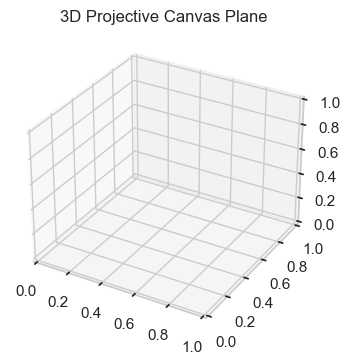

In [2]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(projection='3d')
ax.set_title('3D Projective Canvas Plane')
plt.show()

### 3D Scatter Spaces: `ax.scatter3D()`
**Explanation**: Visualizes 3-feature transaction space: Account Age vs Transaction Amount vs Fraud Flag.

**Syntax**: `ax.scatter3D(df['account_age_months'], df['transaction_amount'], df['is_fraud'])`

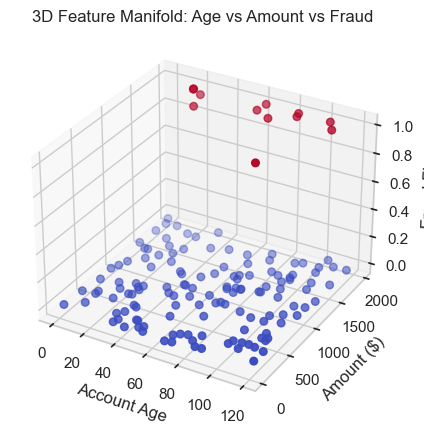

In [3]:
sample = df.head(150)
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(projection='3d')
p = ax.scatter3D(sample['account_age_months'], sample['transaction_amount'], sample['is_fraud'], c=sample['is_fraud'], cmap='coolwarm', s=30)
ax.set_xlabel('Account Age')
ax.set_ylabel('Amount ($)')
ax.set_zlabel('Fraud Flag')
ax.set_title('3D Feature Manifold: Age vs Amount vs Fraud')
plt.show()

### 3D Surface Rendering: `ax.plot_surface()`
**Explanation**: Renders continuous mathematical risk surfaces over meshgrid coordinates.

**Syntax**: `ax.plot_surface(X, Y, Z, cmap='viridis')`

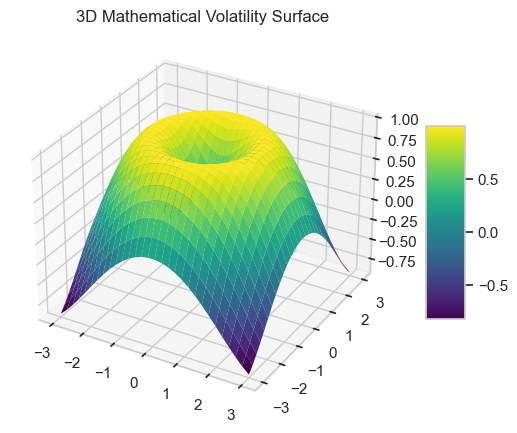

In [4]:
X = np.linspace(-3, 3, 30)
Y = np.linspace(-3, 3, 30)
X, Y = np.meshgrid(X, Y)
Z = np.sin(np.sqrt(X**2 + Y**2))
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
ax.set_title('3D Mathematical Volatility Surface')
plt.show()

### Contour Lines: `ax.contour()`
**Explanation**: Draws level curves mapping equal-density risk contours.

**Syntax**: `ax.contour(X, Y, Z, levels=10)`

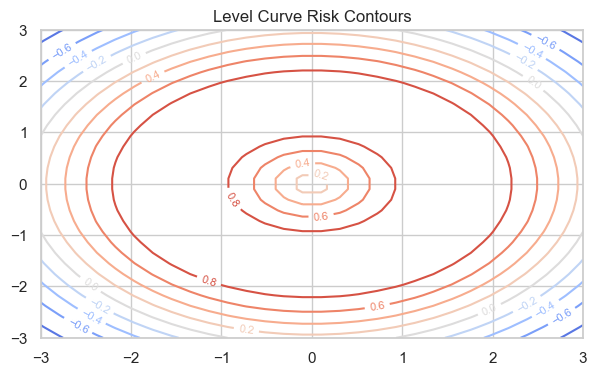

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
cs = ax.contour(X, Y, Z, levels=10, cmap='coolwarm')
ax.clabel(cs, inline=1, fontsize=8)
ax.set_title('Level Curve Risk Contours')
plt.show()

### Filled Contour Maps: `ax.contourf()`
**Explanation**: Renders filled color probability density surfaces.

**Syntax**: `ax.contourf(X, Y, Z, levels=20, cmap='Spectral')`

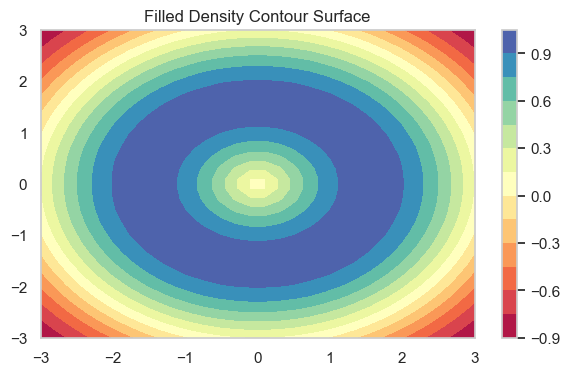

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
cf = ax.contourf(X, Y, Z, levels=15, cmap='Spectral')
fig.colorbar(cf, ax=ax)
ax.set_title('Filled Density Contour Surface')
plt.show()

### Matrix Image Display: `ax.imshow()`
**Explanation**: Renders 2D numeric matrices directly as pixel heat maps.

**Syntax**: `ax.imshow(matrix, cmap='magma', aspect='auto')`

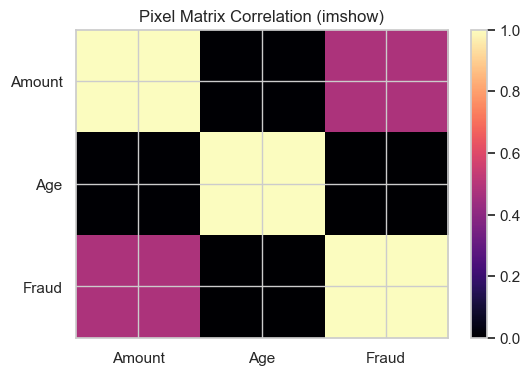

In [7]:
corr_matrix = df[['transaction_amount', 'account_age_months', 'is_fraud']].corr().values
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(corr_matrix, cmap='magma', aspect='auto')
fig.colorbar(im)
ax.set_xticks([0, 1, 2], ['Amount', 'Age', 'Fraud'])
ax.set_yticks([0, 1, 2], ['Amount', 'Age', 'Fraud'])
ax.set_title('Pixel Matrix Correlation (imshow)')
plt.show()

### Polar Coordinates: `projection='polar'`
**Explanation**: Plots circular radar charts mapping metrics along angular radian coordinates.

**Syntax**: `fig.add_subplot(projection='polar')`

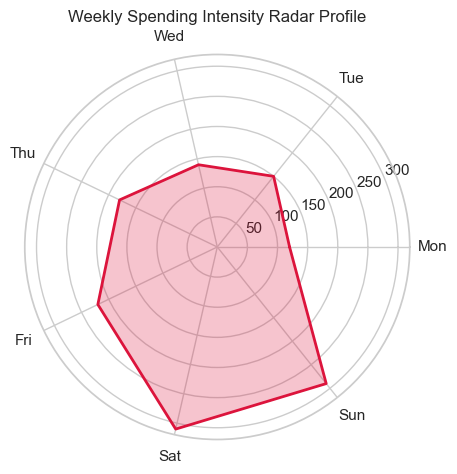

In [8]:
categories = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]
values = [120, 150, 140, 180, 220, 310, 290]
values += values[:1]
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='polar')
ax.plot(angles, values, color='crimson', lw=2)
ax.fill(angles, values, color='crimson', alpha=0.25)
ax.set_thetagrids(np.degrees(angles[:-1]), categories)
ax.set_title('Weekly Spending Intensity Radar Profile')
plt.show()

### Frame Animation: `matplotlib.animation.FuncAnimation()`
**Explanation**: Compiles iterative state updates over sequential frame steps into dynamic animations.

**Syntax**: `FuncAnimation(fig, update_func, frames=10)`

FuncAnimation initialized successfully.


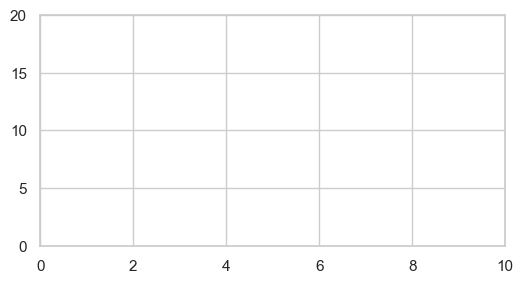

In [9]:
from matplotlib.animation import FuncAnimation
fig, ax = plt.subplots(figsize=(6, 3))
line, = ax.plot([], [], lw=2, color='blue')
def init(): ax.set_xlim(0, 10); ax.set_ylim(0, 20); return line,
def update(frame): line.set_data(np.arange(frame), np.arange(frame)*2); return line,
anim = FuncAnimation(fig, update, frames=8, init_func=init, blit=True)
plt.show()
print('FuncAnimation initialized successfully.')

## Section: Senior Fintech Interview Scenarios (5+ Years Experience)

### Q1: Blitting Optimization in Matplotlib Animations
**Explanation**: Explain how `blit=True` caches static canvas backgrounds and re-draws ONLY modified visual artists for 60 FPS real-time rendering.

**Syntax**: `FuncAnimation(..., blit=True)`

In [10]:
print('Blitting copies pixel buffers of static background elements, re-rendering only dynamic artists.')

Blitting copies pixel buffers of static background elements, re-rendering only dynamic artists.
